In [1]:
#Abertura das Bibliotecas utilizadas
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import netCDF4 as nc
import plotly.express as px
import plotly.graph_objects as go
import cartopy.crs as ccrs # Escolha do sistema de coordenadas
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import matplotlib.patches as mpatches # Desenhar geometria em um mapa
import matplotlib.ticker as mticker
import rasterio

# Carrega os arquivos 

In [2]:
import xarray as xr
import pandas as pd

#PPT_GPCC_1971_1980 = xr.open_dataset("Dados_tmin_tmax/precipitacao_GPCC_1971-1980_America_Sul2.nc")  
PPT_GPCC_1981_1990 = xr.open_dataset("Dados_tmin_tmax/precipitacao_GPCC_1981-1990_America_Sul3.nc") 
PPT_GPCC_1991_2000 = xr.open_dataset("Dados_tmin_tmax/precipitacao_GPCC_1991-2000_America_Sul2.nc") 
PPT_GPCC_2001_2010 = xr.open_dataset("Dados_tmin_tmax/precipitacao_GPCC_2001-2010_America_Sul2.nc") 
PPT_GPCC_2011_2020 = xr.open_dataset("Dados_tmin_tmax/precipitacao_GPCC_2011-2020_America_Sul2.nc")

# Mesclar os dois datasets ao longo do tempo e da localização
PPT_GPCC_1981_2020= xr.merge([PPT_GPCC_1981_1990,PPT_GPCC_1991_2000,PPT_GPCC_2001_2010,PPT_GPCC_2011_2020])

# Salvar se necessário
PPT_GPCC_1981_2020.to_netcdf("Arquivos/PPT_GPCC_1981_2020.nc")

# Exibir informações do dataset final
display(PPT_GPCC_1981_2020)

<xarray.Dataset> Size: 774MB
Dimensions:                       (lon: 224, lat: 300, time: 480)
Coordinates:
  * lon                           (lon) float64 2kB -85.38 -85.12 ... -29.62
  * lat                           (lat) float64 2kB 14.88 14.62 ... -59.88
  * time                          (time) datetime64[ns] 4kB 1981-01-01 ... 20...
Data variables:
    precip                        (time, lat, lon) float32 129MB 7.03 ... nan
    numgauge                      (time, lat, lon) float32 129MB 0.0 0.0 ... 0.0
    infilled_numgauges            (time, lat, lon) float32 129MB 0.0 0.0 ... 0.0
    interpolation_error           (time, lat, lon) float32 129MB 14.26 ... nan
    interpolation_error_infilled  (time, lat, lon) float32 129MB 14.24 ... nan
    diff_new_old_method           (time, lat, lon) float32 129MB 0.0 0.0 ... nan
Attributes: (12/20)
    CDI:                       Climate Data Interface version 1.7.0 (http://m...
    Conventions:               CF-1.4
    history:                   Sat May 28 03:02:51 2022: cdo -setgatts,gattfi...
    title:                     GPCC Full Data Monthly Product Version 2022, p...
    summary:                   The Full Data Monthly Product is of much highe...
    keywords:                  precipitation climatology,gpcc,global,gpcp,
    ...                        ...
    time_coverage_resolution:  month
    geospatial_lat_min:        -90.
    geospatial_lat_max:        90.
    geospatial_lon_min:        -180.
    geospatial_lon_max:        180.
    CDO:                       Climate Data Operators version 1.7.0 (http://m...

In [4]:
import xarray as xr
import rioxarray
from rasterio.enums import Resampling

# Abrir o arquivo NetCDF
ds = xr.open_dataset("Arquivos/PPT_GPCC_1981_2020.nc")

# Selecionar a variável de interesse (ajuste o nome se for diferente)
da = ds["precip"]

# Garantir que o CRS esteja definido como EPSG:4326
if not da.rio.crs:
    da = da.rio.write_crs("EPSG:4326", inplace=False)

# Reprojetar mantendo o CRS em graus e definindo resolução de 0.5 graus
reprojected = da.rio.reproject(
    dst_crs="EPSG:4326",             # Mantém o CRS original (graus)
    resolution=(0.1, 0.1),           # Define nova resolução angular
    resampling=Resampling.bilinear  # Reamostragem bilinear para suavizar
)

reprojected = reprojected.rename({"x": "lon", "y": "lat"})

PPT_GPM = xr.open_dataset("Dados_tmin_tmax/PPT_GPM.nc")

reprojected = reprojected.sel(lat=slice(PPT_GPM['lat'].max().values.item(), PPT_GPM['lat'].min().values.item()), lon=slice(PPT_GPM['lon'].min().values.item(), PPT_GPM['lon'].max().values.item()))
#da_GPCC = reprojected
#reprojected = reprojected.drop_vars("spatial_ref", errors="ignore")
# Padronizar nome da variável
PPT_GPCC = xr.Dataset(
    {
        "PPT": (["time", "lat", "lon"], reprojected.data)
    },
    coords={
        "time": reprojected["time"],
        "lat": PPT_GPM["lat"],
        "lon": PPT_GPM["lon"]
    }
)

#PPT_GPM = xr.open_dataset("Dados_tmin_tmax/PPT_GPM.nc")

#PPT_GPCC = PPT_GPCC.sel(lat=slice(PPT_GPM['lat'].max().values.item(), PPT_GPM['lat'].min().values.item()), lon=slice(PPT_GPM['lon'].min().values.item(), PPT_GPM['lon'].max().values.item()))
# Salvar o resultado reprojetado em um novo arquivo NetCDF
#reprojected.to_netcdf("Arquivos/PPT_GPCC_1971_2020_res.nc")

display(reprojected)
display(PPT_GPCC)
PPT_GPCC.to_netcdf("Arquivos/PPT_GPCC_1981_2020_PPT(2).nc")

<xarray.DataArray 'precip' (time: 480, lat: 750, lon: 551)> Size: 793MB
array([[[ 18.746   ,  24.883   ,  31.814999, ...,        nan,
                nan,        nan],
        [ 19.4013  ,  25.2095  ,  31.5115  , ...,        nan,
                nan,        nan],
        [ 22.0225  ,  26.5155  ,  30.297499, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[131.709   , 157.317   , 174.58499 , ...,        nan,
                nan,        nan],
        [135.907   , 161.1153  , 177.4085  , ...,        nan,
                nan,        nan],
        [152.699   , 176.3085  , 188.7025  , ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[135.165   , 152.89    , 170.33    , ...,        nan,
                nan,        nan],
        [135.9534  , 152.8533  , 168.74251 , ...,        nan,
                nan,        nan],
        [139.107   , 152.7065  , 162.3925  , ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lon          (lon) float64 4kB -84.95 -84.85 -84.75 ... -30.15 -30.05 -29.95
  * lat          (lat) float64 6kB 14.95 14.85 14.75 ... -59.75 -59.85 -59.95
  * time         (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2020-12-01
    spatial_ref  int32 4B 0
Attributes:
    long_name:  gpcc full data monthly product version 2022, precipitation pe...
    units:      mm/month
    code:       20

<xarray.Dataset> Size: 793MB
Dimensions:      (time: 480, lat: 750, lon: 551)
Coordinates:
  * time         (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2020-12-01
    spatial_ref  int32 4B 0
  * lat          (lat) float64 6kB 14.95 14.85 14.75 ... -59.75 -59.85 -59.95
  * lon          (lon) float64 4kB -84.95 -84.85 -84.75 ... -30.15 -30.05 -29.95
Data variables:
    PPT          (time, lat, lon) float32 793MB 18.75 24.88 31.81 ... nan nan

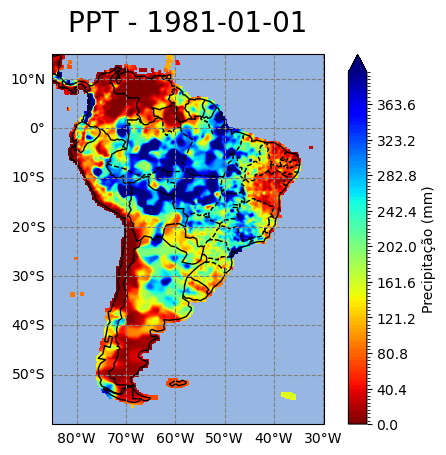

In [8]:
#Criando Mapa de Temperatura Anual média
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs # Escolha do sistema de coordenadas
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import xarray as xr
import cartopy.feature as cfeature

#***********************************************************************************************
Dado = PPT_GPCC
var = 'PPT'
data ='1981-01-01'
#***********************************************************************************************

# Configurar o plot
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
               
Base = Dado[var].sel(time=data) 
# Plotar a média da temperatura
Base.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='jet_r',levels=np.linspace(0, 400, 100), cbar_kwargs={'label': 'Precipitação (mm)'})
#levels=np.linspace(10, 30, 21) é utilizado para definir que a colorBar vai de 10° C até 30°, tendo 21 ponto 


#Adicionando o contorno dos continentes, países e estados do Brasil
#Adicionando o contorno dos continentes
ax.add_feature(cfeature.COASTLINE)

#Adicionando os limites dos países
ax.add_feature(cfeature.BORDERS)

#Adicionando o oceano
ax.add_feature(cfeature.OCEAN)

#Adicionando os limites estaduais
states = cfeature.NaturalEarthFeature(category='cultural',
                                      name='admin_1_states_provinces_lines',
                                      scale='50m',
                                      facecolor='none')
ax.add_feature(states, edgecolor='k', linestyle='--')

#Adicionando título a figura 
ax.set_title(f'{var} - {data}', fontsize=20, y=1.04)

#Adicionando as linhas de grade
g1 = ax.gridlines(crs=ccrs.PlateCarree(), linestyle='--', color='gray', draw_labels=True)

#Formatando os labels como latitude e longitude
g1.yformatter = LATITUDE_FORMATTER
g1.xformatter = LONGITUDE_FORMATTER

#agora irei tirar as grades  superior e direita
# Remove as linhas de grade à direita
g1.ylabels_right = False  # Remove labels do eixo y à direita
g1.right_labels = False  # Remove a linha de grade à direita
g1.y_inline = False  # Evita que as linhas de grade internas sejam desenhadas

# Remove as linhas de grade no topo (se necessário)
g1.xlabels_top = False  # Remove labels do eixo x no topo

# Remove as linhas de grade no topo (se necessário)
g1.xlabels_top = False  # Remove labels do eixo x no topo
g1.top_labels = False  # Remove a linha de grade no topo
